# The audit: corrected estimate against the connection registry

Entry point of the analysis. It compares the corrected per-unit estimates, with their intervals,
against the registry, nationally and unit by unit.

It consumes the outputs of the merge step and performs **no pipeline computation of its own**: only
analysis and figures. That separation is deliberate. A notebook that both built the comparison
tables and drew conclusions from them would make it hard to tell which of the two a discrepancy
came from.

Sections:

1. loading, and verdicts against the 99% interval
2. the entry map, on capacity and on counts
3. descriptive statistics, gaps in MWp and in per cent, with a focus on the flagged units
4. per-unit posteriors with the registry value overlaid

## 1. Chargement et statuts

In [1]:
import sys
from pathlib import Path

import geopandas as gpd
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def _find_root(start, marker='paths.py'):
    for parent in [start, *start.parents]:
        if (parent / marker).exists():
            return parent
    raise FileNotFoundError(marker)

ROOT = _find_root(Path.cwd())
sys.path.insert(0, str(ROOT))
import paths
import style
import dept_posteriors as dp
sys.path.insert(0, str(ROOT / 'code' / '0_pipeline' / 'evaluation' / 'src'))
import helpers   # add_basemap, save_fig, _hide_axis_chrome
style.apply()

TABLE_FILE = paths.EVAL_TABLE
FIGS_DIR = paths.FIGURES
# --- The only configuration that differs between the three audit notebooks ---
REGISTRY_FILE = paths.COMPARISON_DEPT
REGISTRY_LABEL = 'RTE'
OUT_SUFFIX = ''          # suffix of the output tables
FIG_PREFIX = 'comparisons'

comparison = gpd.read_file(REGISTRY_FILE)
# Normalised columns: kWp_rte holds this variant's registry value, whichever registry it is
comparison = comparison.rename(columns={'kWp_rni': 'kWp_rte',
                                        'n_installations_rni': 'n_installations_rte'})
calibration = pd.read_csv(TABLE_FILE, dtype={'dpt': str})
print(f"{len(comparison)} reporting units")

# Verdict against the 99% interval: does the registry value fall inside it?
def status(row, value_col, lo_col, hi_col):
    if pd.isna(row[hi_col]):
        return 'nodata'
    if row[value_col] > row[hi_col]:
        return 'above'    # registry ABOVE the interval: apparent surplus, or local recall overstated
    if row[value_col] < row[lo_col]:
        return 'below'    # registre EN-DESSOUS de l'IC -> capacite manquante au registre
    return 'within'

comparison['status_kwp'] = comparison.apply(
    status, axis=1, value_col='kWp_rte', lo_col='p_inst_ci99_low', hi_col='p_inst_ci99_high')
comparison['status_n'] = comparison.apply(
    status, axis=1, value_col='n_installations_rte', lo_col='n_inst_ci99_low', hi_col='n_inst_ci99_high')
print('statuts kWc :', comparison['status_kwp'].value_counts().to_dict())
print('statuts n   :', comparison['status_n'].value_counts().to_dict())


93 reporting units
statuts kWc : {'within': 60, 'below': 25, 'above': 8}
statuts n   : {'within': 63, 'above': 16, 'below': 14}


## 2. The entry map: registry against the credible interval

Red where the registry lies above the 99% interval, an apparent surplus; blue where it lies below,
meaning capacity absent from the registry; grey where the two are compatible. Intensity gives the
size of the gap.

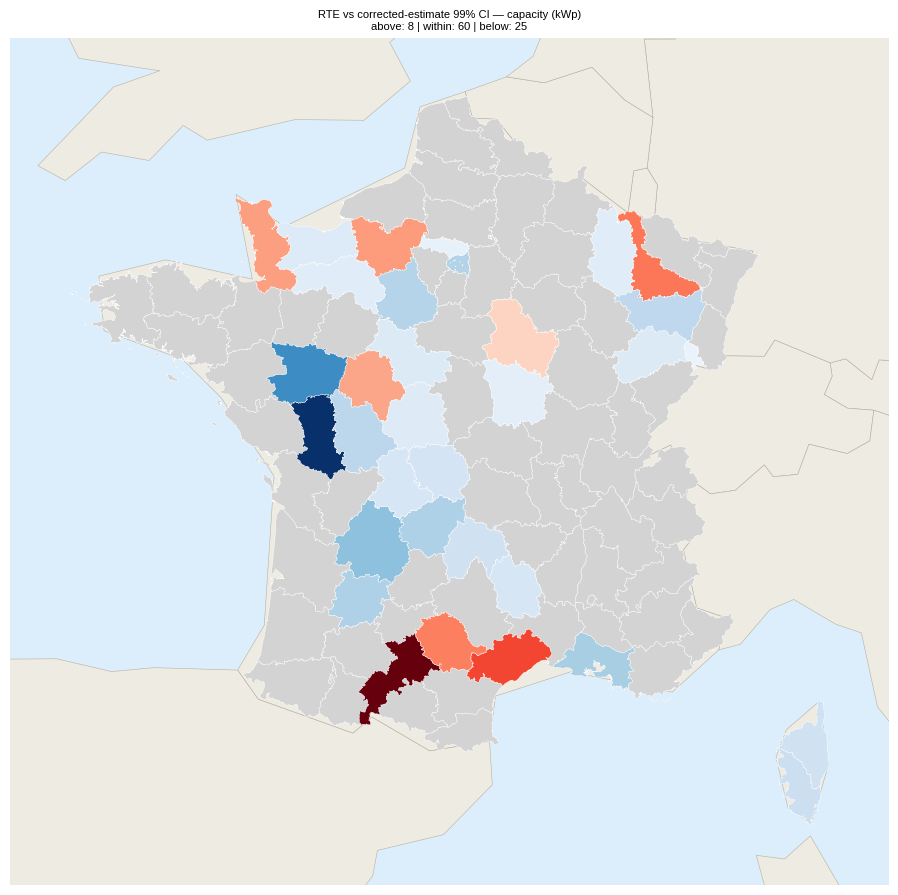

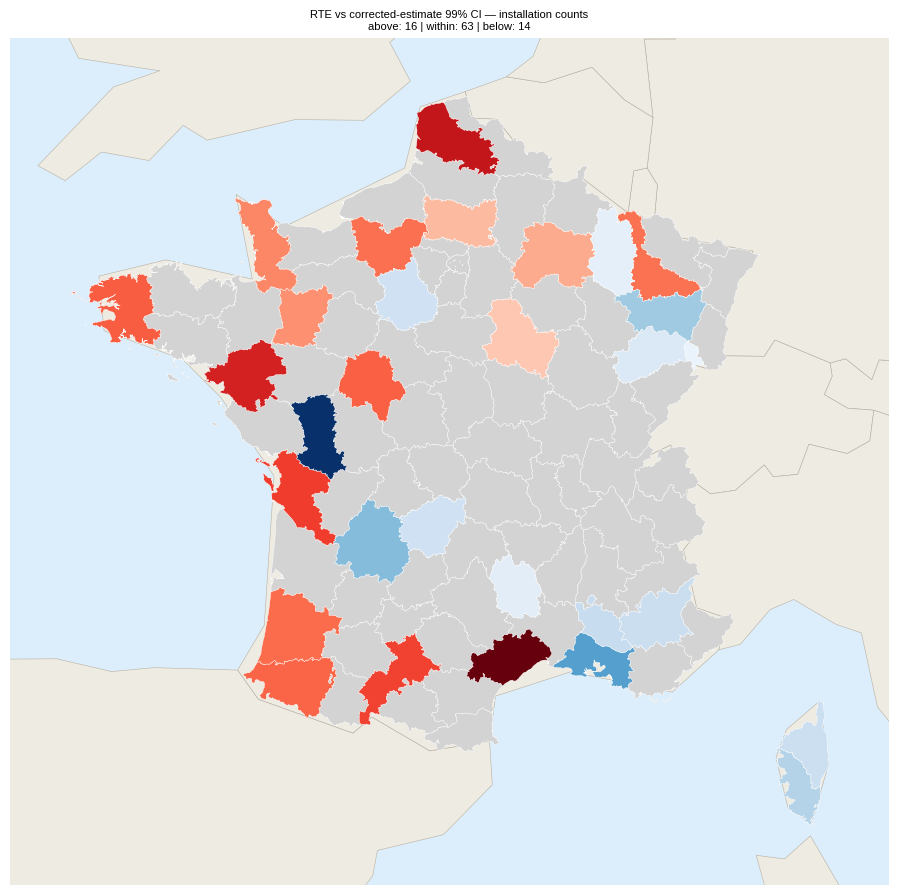

In [2]:
def plot_status_map(comp, status_col, value_col, mean_col, title, filename=None):
    c = comp.copy()
    c['spread'] = c[value_col] - c[mean_col]
    fig, ax = plt.subplots(figsize=(9, 9))
    helpers.add_basemap(ax, c.total_bounds)
    ax.set_aspect(1 / np.cos(np.radians(46.5)))
    for st, color in [('nodata', '#eeeeee'), ('within', 'lightgray')]:
        sub = c[c[status_col] == st]
        if len(sub):
            sub.plot(ax=ax, color=color, edgecolor='white', linewidth=0.3, aspect=None, zorder=1)
    ab = c[c[status_col] == 'above']
    if len(ab):
        ab.plot(ax=ax, color=plt.cm.Reds(mcolors.Normalize(0, max(ab['spread'].max(), 1))(ab['spread'])),
                edgecolor='white', linewidth=0.3, aspect=None, zorder=1)
    be = c[c[status_col] == 'below']
    if len(be):
        be.plot(ax=ax, color=plt.cm.Blues(mcolors.Normalize(0, be['spread'].abs().max())(be['spread'].abs())),
                edgecolor='white', linewidth=0.3, aspect=None, zorder=1)
    helpers._hide_axis_chrome(ax)
    vc = c[status_col].value_counts()
    ax.set_title(f"{title}\nabove: {vc.get('above', 0)} | within: {vc.get('within', 0)} | below: {vc.get('below', 0)}")
    fig.tight_layout()
    if filename:
        helpers.save_fig(fig, filename, FIGS_DIR)
    return fig

fig = plot_status_map(comparison, 'status_kwp', 'kWp_rte', 'p_inst_mean',
                       f'{REGISTRY_LABEL} vs corrected-estimate 99% CI — capacity (kWp)',
                       f'{FIG_PREFIX}_status_map_kwp.png')
plt.show()
fig = plot_status_map(comparison, 'status_n', 'n_installations_rte', 'n_inst_mean',
                       f'{REGISTRY_LABEL} vs corrected-estimate 99% CI — installation counts',
                       f'{FIG_PREFIX}_status_map_n.png')
plt.show()


In [3]:
comparison[comparison['status_kwp']=="below"].columns

Index(['dpt', 'nom', 'n_inst_raw', 'p_inst_raw', 'n_inst_mean',
       'n_inst_ci95_low', 'n_inst_ci95_high', 'n_inst_ci99_low',
       'n_inst_ci99_high', 'p_inst_mean', 'p_inst_ci95_low',
       'p_inst_ci95_high', 'p_inst_ci99_low', 'p_inst_ci99_high',
       'n_installations_rte', 'kWp_rte', 'geometry', 'status_kwp', 'status_n'],
      dtype='object')

## 3. Descriptive statistics: gaps in MWp and in per cent

Sign convention, which is worth fixing once: **gap = corrected minus registry**, so a positive gap
means capacity absent from the registry. The relative gap is expressed as a share of the corrected
estimate, readable as the share of the estimated fleet missing from the registry. The coverage
column is its complement, the registry as a share of the corrected estimate.

In [4]:
# --- national ---
tot_dpvm = comparison['p_inst_mean'].sum()
tot_rte = comparison['kWp_rte'].sum()
gap = tot_dpvm - tot_rte
print(f"NATIONAL (kWc)")
print(f"  corrected : {tot_dpvm/1000:8,.1f} MWp")
print(f"  RTE           : {tot_rte/1000:8,.1f} MWc")
print(f"  gap       : {gap/1000:+8,.1f} MWp  ({gap/tot_dpvm:+.1%} of the corrected estimate)")

tot_dpvm_n = comparison['n_inst_mean'].sum()
tot_rte_n = comparison['n_installations_rte'].sum()
print(f"\nNATIONAL (n installations)")
print(f"  corrected : {tot_dpvm_n:10,.0f} | registry : {tot_rte_n:10,.0f} | "
      f"gap : {tot_dpvm_n - tot_rte_n:+,.0f} ({(tot_dpvm_n - tot_rte_n)/tot_dpvm_n:+.1%})")

# Lower bound on the national gap: gaps measured to the interval bound, flagged units only
below = comparison[comparison['status_kwp'] == 'below']
lower_bound = (below['p_inst_ci99_low'] - below['kWp_rte']).sum()
print(f"\nlower bound (gaps to the 99% lower bound, under-reported units only): {lower_bound/1000:,.1f} MWp")


NATIONAL (kWc)
  corrected :  4,033.0 MWp
  RTE           :  3,900.7 MWc
  gap       :   +132.3 MWp  (+3.3% of the corrected estimate)

NATIONAL (n installations)
  corrected :    822,981 | registry :    853,469 | gap : -30,488 (-3.7%)

lower bound (gaps to the 99% lower bound, under-reported units only): 76.5 MWp


In [5]:
# --- Per-unit gap table ---
d = comparison[['dpt', 'nom', 'status_kwp', 'status_n',
                'p_inst_raw', 'p_inst_mean', 'p_inst_ci99_low', 'p_inst_ci99_high', 'kWp_rte',
                'n_inst_mean', 'n_installations_rte']].copy()
d['ecart_MW'] = (d['p_inst_mean'] - d['kWp_rte']) / 1000
d['ecart_pct'] = (d['p_inst_mean'] - d['kWp_rte']) / d['p_inst_mean']
d['couverture_rte'] = d['kWp_rte'] / d['p_inst_mean']
d['ecart_n_pct'] = (d['n_inst_mean'] - d['n_installations_rte']) / d['n_inst_mean']

print(f"relative gap: median {d['ecart_pct'].median():+.1%} | "
      f"IQR [{d['ecart_pct'].quantile(.25):+.1%}, {d['ecart_pct'].quantile(.75):+.1%}]")
d.to_csv(paths.AUDIT_RTE, index=False)
print(f'Ecrit : comparison_ecarts_departements{OUT_SUFFIX}.csv')


relative gap: median +4.7% | IQR [-4.5%, +19.4%]
Ecrit : comparison_ecarts_departements.csv


### 3.1 Flagged units, by relative gap

Under-reported units sorted by decreasing relative gap. Over-reported units in a separate table:
they are candidates for investigation rather than findings, since a local recall underestimate is
a more likely explanation than a registry surplus.

In [6]:
cols = ['dpt', 'nom', 'ecart_MW', 'ecart_pct', 'couverture_rte', 'ecart_n_pct',
        'p_inst_mean', 'kWp_rte']
fmt = {'ecart_MW': '{:+.1f}', 'ecart_pct': '{:+.1%}', 'couverture_rte': '{:.0%}',
       'ecart_n_pct': '{:+.1%}', 'p_inst_mean': '{:,.0f}', 'kWp_rte': '{:,.0f}'}

flagged_below = d[d['status_kwp'] == 'below'].sort_values('ecart_pct', ascending=False)
print(f"UNDER-REPORTED ({len(flagged_below)} units), by decreasing relative gap:")
display(flagged_below[cols].style.format(fmt).hide(axis='index'))

total_below = flagged_below['ecart_MW'].sum()
print(f"total over the under-reported units: {total_below:,.1f} MWp "
      f"({total_below*1000/tot_dpvm:.1%} of the national corrected fleet)")


UNDER-REPORTED (25 units), by decreasing relative gap:


dpt,nom,ecart_MW,ecart_pct,couverture_rte,ecart_n_pct,p_inst_mean,kWp_rte
2A,Corse-du-Sud,+8.0,+60.8%,39%,+66.5%,"13,081","5,128"
2B,Haute-Corse,+7.1,+56.1%,44%,+60.2%,"12,668","5,561"
79,Deux-Sèvres,+36.0,+53.2%,47%,+52.1%,"67,664","31,653"
28,Eure-et-Loir,+10.9,+47.5%,52%,+31.2%,"22,911","12,025"
19,Corrèze,+11.7,+40.0%,60%,+25.3%,"29,258","17,567"
48,Lozère,+5.9,+36.8%,63%,+26.4%,"16,112","10,184"
23,Creuse,+6.4,+36.0%,64%,+19.6%,"17,778","11,380"
75PC,Paris + petite couronne,+11.2,+32.4%,68%,+8.0%,"34,528","23,355"
90,Territoire de Belfort,+2.3,+31.2%,69%,+20.5%,"7,267","5,002"
36,Indre,+4.5,+29.7%,70%,+9.2%,"15,234","10,709"


total over the under-reported units: 228.2 MWp (5.7% of the national corrected fleet)


In [7]:
cols = [
    'dpt', 'nom', 'ecart_MW', 'ecart_pct',
    'couverture_rte',
    'p_inst_mean', 'kWp_rte'
]

fmt = {
    'ecart_MW': '{:+.1f}',
    'ecart_pct': '{:+.1%}',
    'couverture_rte': '{:.0%}',
    'p_inst_mean': '{:,.0f}',
    'kWp_rte': '{:,.0f}',
}

flagged_below = (
    d[d['status_kwp'] == 'below']
    .sort_values('ecart_pct', ascending=False)
)

latex_df = flagged_below[cols].copy()

for col, f in fmt.items():
    latex_df[col] = latex_df[col].map(lambda x: f.format(x))

print(
    latex_df.to_latex(
        index=False,
        escape=False,
        column_format="llrrrrrr",
        caption="Units (departements) where the connected installed capacity is lower than the estimated capacity (lower than the 99% CI lower bound).",
        label="tab:below_departements",
    )
)

\begin{table}
\caption{Units (departements) where the connected installed capacity is lower than the estimated capacity (lower than the 99% CI lower bound).}
\label{tab:below_departements}
\begin{tabular}{llrrrrrr}
\toprule
dpt & nom & ecart_MW & ecart_pct & couverture_rte & p_inst_mean & kWp_rte \\
\midrule
2A & Corse-du-Sud & +8.0 & +60.8% & 39% & 13,081 & 5,128 \\
2B & Haute-Corse & +7.1 & +56.1% & 44% & 12,668 & 5,561 \\
79 & Deux-Sèvres & +36.0 & +53.2% & 47% & 67,664 & 31,653 \\
28 & Eure-et-Loir & +10.9 & +47.5% & 52% & 22,911 & 12,025 \\
19 & Corrèze & +11.7 & +40.0% & 60% & 29,258 & 17,567 \\
48 & Lozère & +5.9 & +36.8% & 63% & 16,112 & 10,184 \\
23 & Creuse & +6.4 & +36.0% & 64% & 17,778 & 11,380 \\
75PC & Paris + petite couronne & +11.2 & +32.4% & 68% & 34,528 & 23,355 \\
90 & Territoire de Belfort & +2.3 & +31.2% & 69% & 7,267 & 5,002 \\
36 & Indre & +4.5 & +29.7% & 70% & 15,234 & 10,709 \\
24 & Dordogne & +15.0 & +28.5% & 72% & 52,587 & 37,609 \\
86 & Vienne & +10.3 & +27.

In [8]:
flagged_above = d[d['status_kwp'] == 'above'].sort_values('ecart_pct')
print(f"OVER-REPORTED ({len(flagged_above)} units), registry above the interval:")
display(flagged_above[cols].style.format(fmt).hide(axis='index'))

flagged_above = flagged_above['ecart_MW'].sum()
print(f"total over the over-reported units: {flagged_above:,.1f} MWp "
      f"({flagged_above*1000/tot_dpvm:.1%} of the national corrected fleet)")



OVER-REPORTED (8 units), registry above the interval:


dpt,nom,ecart_MW,ecart_pct,couverture_rte,p_inst_mean,kWp_rte
89,Yonne,-4.5,-52.7%,153%,"8,611","13,145"
27,Eure,-9.4,-44.9%,145%,"20,894","30,280"
50,Manche,-9.2,-40.2%,140%,"22,834","32,021"
54,Meurthe-et-Moselle,-12.5,-39.5%,140%,"31,621","44,124"
37,Indre-et-Loire,-8.5,-37.8%,138%,"22,532","31,043"
31,Haute-Garonne,-27.2,-22.7%,123%,"120,032","147,219"
81,Tarn,-11.9,-20.0%,120%,"59,364","71,254"
34,Hérault,-16.2,-14.7%,115%,"110,266","126,475"


total over the over-reported units: -99.4 MWp (-2.5% of the national corrected fleet)


## 4. Per-unit posteriors with the registry value overlaid

Drawn through the shared module, with the same Beta parameters as the main chain and the same
seed. The histogram therefore **is** the distribution the correction summarises, not a
re-derivation of it that could drift out of step.

The vertical line is the registry value, and the verdict is read directly off it: outside the band
means flagged.

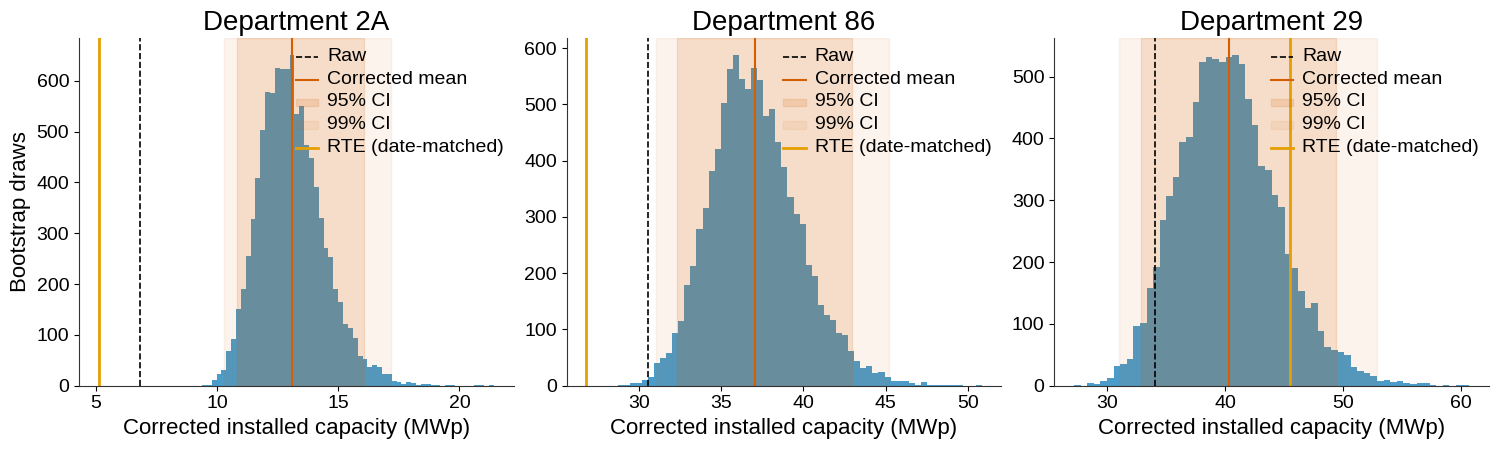

In [9]:
# --- 4.1 : set de 3 departements, figure sauvegardee ---
SELECTED_DEPTS = ['2A', '86', '29']   # a ajuster : ex. 2 below marquants + 1 within

draws = dp.compute_dept_draws(SELECTED_DEPTS, calibration, comparison)
ref_values = comparison.set_index('dpt')['kWp_rte'].to_dict()

fig = dp.plot_depts(
    draws,
    ref_values=ref_values,
    quantity='p_inst',
    unit_scale=1e-3,
)

# -------------------------------
# Enlarge the text
# -------------------------------
for ax in fig.axes:
    # Titre
    ax.set_title(ax.get_title(), fontsize=20)

    # Axes
    ax.set_xlabel(ax.get_xlabel(), fontsize=16)
    ax.set_ylabel(ax.get_ylabel(), fontsize=16)

    # Graduations
    ax.tick_params(axis='both', labelsize=14)

    # Legend, if present
    leg = ax.get_legend()
    if leg is not None:
        leg.set_title(leg.get_title().get_text(), prop={'size': 14})
        for txt in leg.get_texts():
            txt.set_fontsize(14)

fig.tight_layout()

helpers.save_fig(
    fig,
    f'{FIG_PREFIX}_posteriors_{"_".join(SELECTED_DEPTS)}.pdf',
    FIGS_DIR,
)

plt.show()

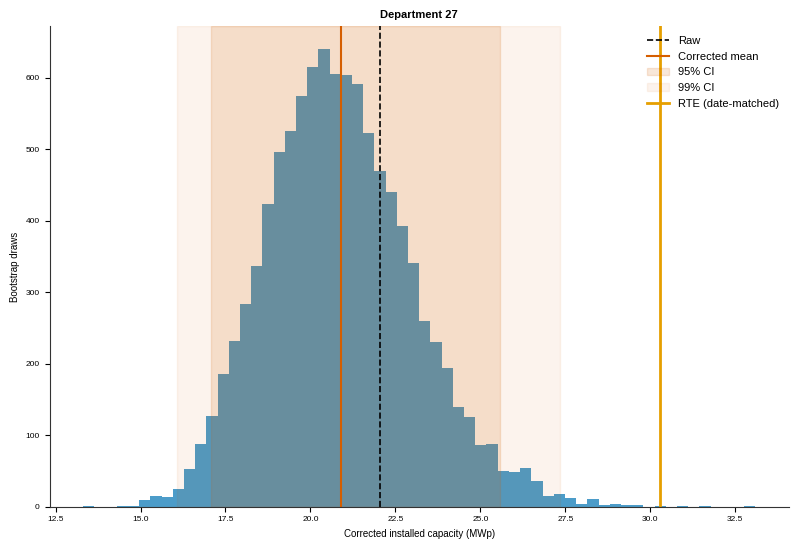

Unit 27 (Eure) - verdict: above
  raw     22.0 MWp -> corrected     20.9 MWp [IC99 16.1 – 27.3]
  RTE      30.3 MWc  (couverture 145%, gap -9.4 MWp)
  calibration : P = 0.53 (n=228), R = 0.55 (n=83), facteur = 0.95 ± 20%


In [10]:
# --- 4.2: a single unit, for inspection ---
DEBUG_DEPT = '27'

draws_1 = dp.compute_dept_draws([DEBUG_DEPT], calibration, comparison)
fig, ax = plt.subplots(figsize=(8, 5.5))
dp.plot_dept_posterior(ax, DEBUG_DEPT, draws_1[DEBUG_DEPT], quantity='p_inst',
                        ref_value=ref_values.get(DEBUG_DEPT), unit_scale=1e-3)
ax.set_ylabel('Bootstrap draws')
plt.tight_layout()
plt.show()

r = comparison.set_index('dpt').loc[DEBUG_DEPT]
c = calibration.set_index('dpt').loc[DEBUG_DEPT]
print(f"Unit {DEBUG_DEPT} ({r['nom']}) - verdict: {r['status_kwp']}")
print(f"  raw {r['p_inst_raw']/1000:8,.1f} MWp -> corrected {r['p_inst_mean']/1000:8,.1f} MWp "
      f"[IC99 {r['p_inst_ci99_low']/1000:,.1f} – {r['p_inst_ci99_high']/1000:,.1f}]")
print(f"  RTE  {r['kWp_rte']/1000:8,.1f} MWc  (couverture {r['kWp_rte']/r['p_inst_mean']:.0%}, "
      f"gap {(r['p_inst_mean']-r['kWp_rte'])/1000:+,.1f} MWp)")
print(f"  calibration : P = {c['precision']:.2f} (n={c['n_precision']:.0f}), "
      f"R = {c['recall']:.2f} (n={c['n_recall']:.0f}), facteur = {c['correction_factor_mean']:.2f} "
      f"± {c['correction_factor_rel_uncertainty']/2:.0%}")


## 5. Robustness battery: specification uncertainty

Every figure in this audit carries two uncertainties of different kinds, and conflating them would
be the easiest mistake to make here.

**Sampling uncertainty** is how many points were annotated, and it lives in the credible intervals.
**Specification uncertainty** is the set of modelling choices a reasonable analyst could have made
differently: which weighting, which coefficient. It is not in the intervals, and it is what this
battery measures, in the spirit of specification curve analysis (Simonsohn et al. 2020; Steegen et
al. 2016).

The paper's central estimator stays single and simple, counted P/R under the empirical-Bayes prior.
The battery bounds everything else. **No additional correction is stacked on top**, which is the
discipline that keeps the exercise honest: a battery that quietly improved the estimator at each
step would be measuring its own additions rather than the specification uncertainty.

- **A, baseline**: the counted P/R factor of section 1.
- **B, size-weighted**: the factor P_w/R_w, precision and recall weighted by capacity, measured on
  the annotated samples. It addresses the moderate homogeneity violation on the precision side,
  false positives being slightly larger than true positives. On the recall side the weighted rate
  is measurable only on ground truth carrying a size, so it falls back to the counted recall below
  a minimum sample. B is **invariant to the conversion coefficient**, which cancels in both ratios,
  so B and C probe orthogonal directions.
- **C, conversion**: the surface-to-capacity coefficient at 5.0 and 6.0 m2/kWp around the 5.5
  retained, about ±9% on the estimate.
- **D, installation counts**: the verdict on counts rather than capacity. Independent of any
  conversion, but noisy because an array and a contract are not the same object. Used as a
  non-contradiction check only.

The **hard core** is unanimity across the specifications, with the negative control read
symmetrically: units flagged over-reported by every specification. A method that manufactured
discrepancies would produce those in comparable numbers, which is exactly what makes them a
control.

In [11]:
# --- Specification B: the size-weighted factor, read from the scores table ---
MIN_N_RECALL_KWP = 40

cal = calibration.set_index('dpt')
rb = comparison.merge(calibration[['dpt', 'precision', 'recall', 'precision_kwp',
                                    'recall_kwp', 'n_recall_kwp']], on='dpt', how='left')

# Weighted recall falls back to the counted one when too few ground-truth points carry a size
rb['recall_B'] = np.where(rb['n_recall_kwp'].fillna(0) >= MIN_N_RECALL_KWP,
                           rb['recall_kwp'], rb['recall'])
rb['scale_B'] = ((rb['precision_kwp'] / rb['recall_B']) /
                 (rb['precision'] / rb['recall'])).fillna(1.0)
n_fallback = (rb['n_recall_kwp'].fillna(0) < MIN_N_RECALL_KWP).sum()
print(f"specification B: {n_fallback} units fall back to the counted recall "
      f"(fewer than {MIN_N_RECALL_KWP} sized ground-truth points)")


specification B: 59 units fall back to the counted recall (fewer than 40 sized ground-truth points)


In [12]:
# --- Verdicts under each specification, and the spec range ---
def status_scaled(row, scale):
    hi, lo = row['p_inst_ci99_high'] * scale, row['p_inst_ci99_low'] * scale
    if pd.isna(hi):
        return 'nodata'
    return 'above' if row['kWp_rte'] > hi else ('below' if row['kWp_rte'] < lo else 'within')

SCALES = {'A': lambda r: 1.0, 'B': lambda r: r['scale_B'],
          'C_50': lambda r: 5.5 / 5.0, 'C_60': lambda r: 5.5 / 6.0}
for name, fn in SCALES.items():
    rb[f'status_{name}'] = rb.apply(lambda r: status_scaled(r, fn(r)), axis=1)
    rb[f'est_{name}'] = rb.apply(lambda r: r['p_inst_mean'] * fn(r), axis=1)
rb['status_D'] = rb['dpt'].map(comparison.set_index('dpt')['status_n'])

# Spec range: min to max of the central estimate across specifications
est_cols = [f'est_{n}' for n in SCALES]
rb['est_spec_min'] = rb[est_cols].min(axis=1)
rb['est_spec_max'] = rb[est_cols].max(axis=1)

specs = [f'status_{n}' for n in SCALES]
for s_ in specs + ['status_D']:
    print(f"{s_:>11} :", rb[s_].value_counts().to_dict())


   status_A : {'within': 60, 'below': 25, 'above': 8}
   status_B : {'within': 57, 'below': 22, 'above': 14}
status_C_50 : {'within': 51, 'below': 37, 'above': 5}
status_C_60 : {'within': 59, 'above': 19, 'below': 15}
   status_D : {'within': 63, 'above': 16, 'below': 14}


In [13]:
# --- hard core (unanimite A-B) + sensibilite conversion, rendu "deux crochets" ---
# The core is unanimity across A and B at the baseline coefficient.
#
# Conversion (C) is NOT a unanimity criterion but a ROBUSTNESS INDICATOR: a unit
# whose verdict changes at either bound is flagged conversion_sensitive and keeps
# its baseline direction. Treating C as a third vote would count the same degree
# of freedom twice, since it is monotone in a single parameter.
#
# Specification D, on counts, stays outside the definition and serves only as a
# non-contradiction check below.
rb['conversion_sensitive'] = (rb['status_C_50'] != rb['status_A']) | (rb['status_C_60'] != rb['status_A'])
rb['hard_core_below'] = (rb['status_A'] == 'below') & (rb['status_B'] == 'below')
rb['hard_core_above'] = (rb['status_A'] == 'above') & (rb['status_B'] == 'above')

hc = rb[rb['hard_core_below']].copy()
hc['couverture_rte'] = hc['kWp_rte'] / hc['p_inst_mean']
hc['ecart_MW'] = (hc['p_inst_mean'] - hc['kWp_rte']) / 1000
hc['ecart_MW_specmin'] = (hc['est_spec_min'] - hc['kWp_rte']) / 1000   # lower bound on the gap
hc = hc.sort_values('couverture_rte')
_rob = hc[~hc['conversion_sensitive']]
print(f"HARD CORE, under-reported: {len(hc)} units | cumulative gap {hc['ecart_MW'].sum():,.0f} MWp "
      f"(borne basse spec : {hc['ecart_MW_specmin'].sum():,.0f} MWc)")
print(f"  of which insensitive to the conversion coefficient: {len(_rob)} ({_rob['ecart_MW'].sum():,.0f} MWp); "
      f"sensibles (statut baseline conserve, flag robustesse) : {sorted(hc.loc[hc['conversion_sensitive'], 'dpt'])}")

# rendu deux crochets : estimation [IC95] [spec range]
hc['rendu'] = hc.apply(
    lambda r: f"{r['p_inst_mean']/1000:,.1f} MWc "
              f"[IC95 {r['p_inst_ci95_low']/1000:,.1f}–{r['p_inst_ci95_high']/1000:,.1f}] "
              f"[spec {r['est_spec_min']/1000:,.1f}–{r['est_spec_max']/1000:,.1f}] "
              f"vs RTE {r['kWp_rte']/1000:,.1f}", axis=1)
display(hc[['dpt', 'nom', 'couverture_rte', 'ecart_MW', 'ecart_MW_specmin', 'rendu']]
        .style.format({'couverture_rte': '{:.0%}', 'ecart_MW': '{:+.1f}', 'ecart_MW_specmin': '{:+.1f}'})
        .hide(axis='index'))

# check de concordance D (diagnostic annexe, hors definition)
for _lbl, _mask in [('below', rb['hard_core_below']), ('above', rb['hard_core_above'])]:
    _d = rb.loc[_mask, 'status_D'].value_counts().to_dict()
    print(f"count-based concordance on the {_lbl} core: {_d}")

hca = rb[rb['hard_core_above']]
print(f"dont sensibles conversion : {sorted(hca.loc[hca['conversion_sensitive'], 'dpt'])}")
print(f"\nHARD CORE ABOVE (controle negatif) : {len(hca)} departements")
if len(hca):
    display(hca[['dpt', 'nom', 'precision', 'precision_kwp', 'recall']].round(3))

n_any = ((rb[specs] == 'below').any(axis=1)).sum()
print(f"\nReading: {n_any} units under-reported under at least one specification, {len(hc)} under "
      f"all of them. Hard-core asymmetry: {len(hc)} below against {len(hca)} above.")
rb.drop(columns='geometry').to_csv(paths.SPECS_RTE, index=False)
print(f'Ecrit : robustness_specs_departements{OUT_SUFFIX}.csv')


HARD CORE, under-reported: 18 units | cumulative gap 172 MWp (borne basse spec : 125 MWc)
  of which insensitive to the conversion coefficient: 14 (141 MWp); sensibles (statut baseline conserve, flag robustesse) : ['13', '14', '61', '88']


dpt,nom,couverture_rte,ecart_MW,ecart_MW_specmin,rendu
2A,Corse-du-Sud,39%,+8.0,+6.9,13.1 MWc [IC95 10.8–16.0] [spec 12.0–14.4] vs RTE 5.1
2B,Haute-Corse,44%,+7.1,+6.1,12.7 MWc [IC95 10.9–14.9] [spec 11.6–13.9] vs RTE 5.6
79,Deux-Sèvres,47%,+36.0,+30.4,67.7 MWc [IC95 53.9–86.2] [spec 62.0–74.4] vs RTE 31.7
28,Eure-et-Loir,52%,+10.9,+9.0,22.9 MWc [IC95 19.1–27.5] [spec 21.0–25.2] vs RTE 12.0
19,Corrèze,60%,+11.7,+9.3,29.3 MWc [IC95 23.5–36.6] [spec 26.8–32.2] vs RTE 17.6
48,Lozère,63%,+5.9,+4.6,16.1 MWc [IC95 13.1–20.3] [spec 14.8–17.7] vs RTE 10.2
23,Creuse,64%,+6.4,+4.9,17.8 MWc [IC95 14.6–22.1] [spec 16.3–19.6] vs RTE 11.4
75PC,Paris + petite couronne,68%,+11.2,+8.3,34.5 MWc [IC95 30.6–38.9] [spec 31.7–38.0] vs RTE 23.4
90,Territoire de Belfort,69%,+2.3,+1.6,7.3 MWc [IC95 6.4–8.3] [spec 6.6–8.0] vs RTE 5.0
24,Dordogne,72%,+15.0,+10.6,52.6 MWc [IC95 43.6–64.4] [spec 48.2–57.8] vs RTE 37.6


count-based concordance on the below core: {'below': 12, 'within': 6}
count-based concordance on the above core: {'above': 6, 'within': 1}
dont sensibles conversion : ['37', '81']

HARD CORE ABOVE (controle negatif) : 7 departements


,dpt,nom,precision,precision_kwp,recall
25,27,Eure,0.526,0.516,0.552
31,31,Haute-Garonne,0.958,0.947,0.690
37,37,Indre-et-Loire,0.639,0.629,0.511
50,50,Manche,0.679,0.697,0.634
54,54,Meurthe-et-Moselle,0.708,0.620,0.703
81,81,Tarn,0.925,0.819,0.776
89,89,Yonne,0.675,0.611,0.679



Reading: 39 units under-reported under at least one specification, 18 under all of them. Hard-core asymmetry: 18 below against 7 above.
Ecrit : robustness_specs_departements.csv


### 5.1 Status map, by the specifications included

The same map as section 2, but the verdict is recomputed by **unanimity across the selected
specifications**: a unit is flagged only if it is flagged under all of them. A unit flagged under
some but not all appears as mixed, hatched, which is specification uncertainty made visible rather
than summarised away.

Selecting A alone returns the section 2 map; the full list gives the hard core.

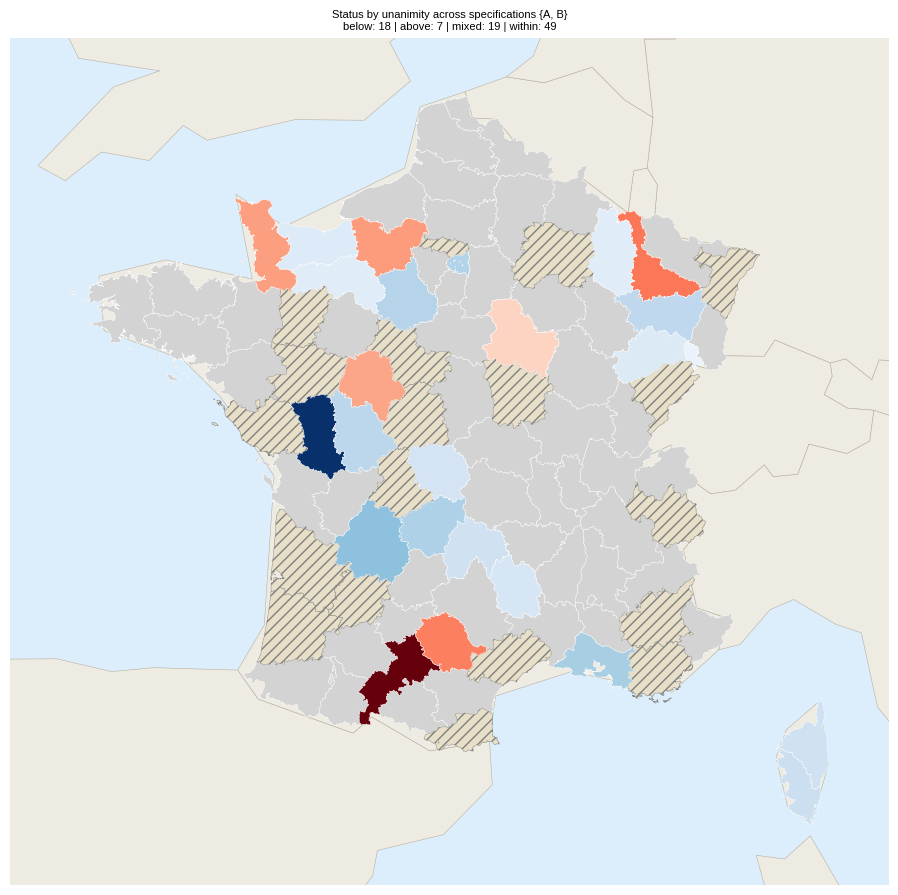

In [14]:
INCLUDE_SPECS = ['A', 'B']   # noyau = unanimite A-B ; C = flag de sensibilite (hachures)

sel = [f'status_{s}' for s in INCLUDE_SPECS]
n_below = (rb[sel] == 'below').sum(axis=1)
n_above = (rb[sel] == 'above').sum(axis=1)
rb['status_sel'] = np.select(
    [n_below == len(sel), n_above == len(sel), (n_below > 0) | (n_above > 0)],
    ['below', 'above', 'mixed'], default='within')

c = rb.copy()
c['spread'] = c['kWp_rte'] - c['p_inst_mean']
fig, ax = plt.subplots(figsize=(9, 9))
helpers.add_basemap(ax, c.total_bounds)
ax.set_aspect(1 / np.cos(np.radians(46.5)))
for st, kw in [('nodata', dict(color='#eeeeee')), ('within', dict(color='lightgray')),
               ('mixed', dict(color='#e8dfc8', hatch='///', edgecolor='gray'))]:
    sub = c[c['status_sel'] == st]
    if len(sub):
        sub.plot(ax=ax, linewidth=0.3, aspect=None, zorder=1, **{k: v for k, v in kw.items() if k != 'edgecolor'},
                 **({'edgecolor': kw['edgecolor']} if 'edgecolor' in kw else {'edgecolor': 'white'}))
ab = c[c['status_sel'] == 'above']
if len(ab):
    ab.plot(ax=ax, color=plt.cm.Reds(mcolors.Normalize(0, max(ab['spread'].max(), 1))(ab['spread'])),
            edgecolor='white', linewidth=0.3, aspect=None, zorder=1)
be = c[c['status_sel'] == 'below']
if len(be):
    be.plot(ax=ax, color=plt.cm.Blues(mcolors.Normalize(0, be['spread'].abs().max())(be['spread'].abs())),
            edgecolor='white', linewidth=0.3, aspect=None, zorder=1)
helpers._hide_axis_chrome(ax)
vc = c['status_sel'].value_counts()
ax.set_title(f"Status by unanimity across specifications {{{', '.join(INCLUDE_SPECS)}}}\n"
             f"below: {vc.get('below', 0)} | above: {vc.get('above', 0)} | "
             f"mixed: {vc.get('mixed', 0)} | within: {vc.get('within', 0)}")
fig.tight_layout()
helpers.save_fig(fig, f"{FIG_PREFIX}_status_map_specs_{'_'.join(INCLUDE_SPECS)}.png", FIGS_DIR)
plt.show()


## Same plot as above, cleaner reading

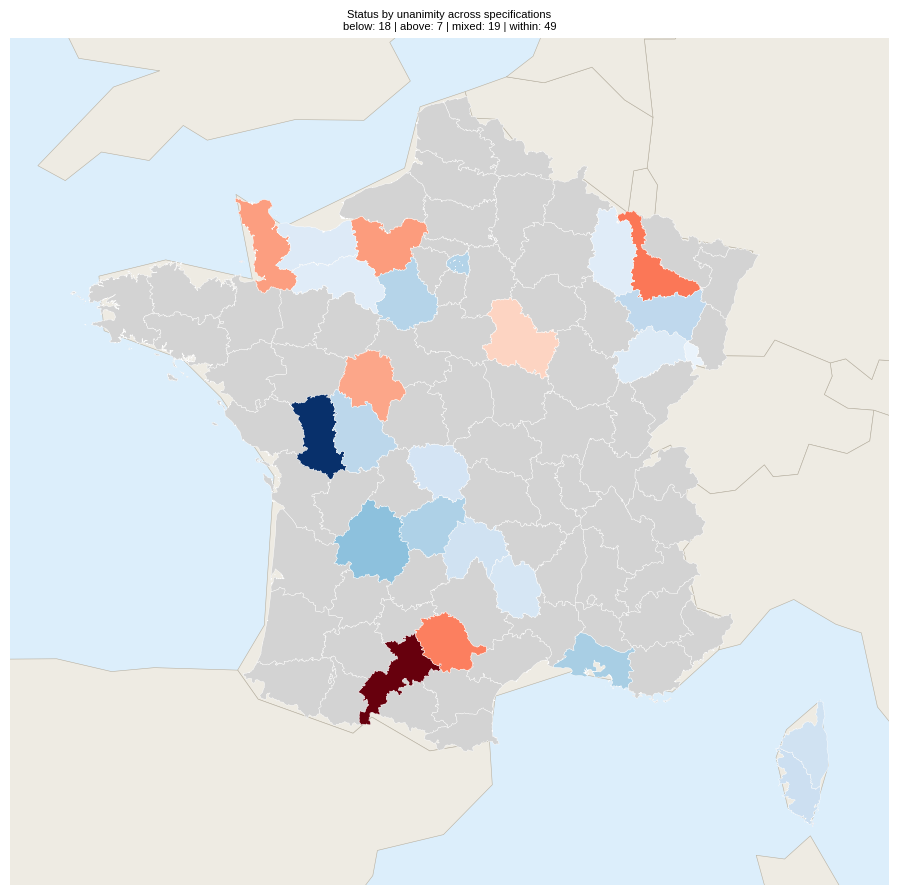

In [15]:
INCLUDE_SPECS = ['A', 'B']   # noyau = unanimite A-B ; C = flag de sensibilite (hachures)

sel = [f'status_{s}' for s in INCLUDE_SPECS]
n_below = (rb[sel] == 'below').sum(axis=1)
n_above = (rb[sel] == 'above').sum(axis=1)

rb['status_sel'] = np.select(
    [
        n_below == len(sel),
        n_above == len(sel),
        (n_below > 0) | (n_above > 0),
    ],
    ['below', 'above', 'mixed'],
    default='within',
)

c = rb.copy()
c['spread'] = c['kWp_rte'] - c['p_inst_mean']

fig, ax = plt.subplots(figsize=(9, 9))
helpers.add_basemap(ax, c.total_bounds)
ax.set_aspect(1 / np.cos(np.radians(46.5)))

# ------------------------------------------------------------------
# Grey units, no hatching
# ------------------------------------------------------------------
for st, color in [
    ('nodata', '#eeeeee'),
    ('within', 'lightgray'),
    ('mixed', 'lightgray'),
]:
    sub = c[c['status_sel'] == st]
    if len(sub):
        sub.plot(
            ax=ax,
            color=color,
            edgecolor='white',
            linewidth=0.3,
            aspect=None,
            zorder=1,
        )

# ------------------------------------------------------------------
# Over-reported units, red
# ------------------------------------------------------------------
ab = c[c['status_sel'] == 'above']
if len(ab):
    norm = mcolors.Normalize(0, max(ab['spread'].max(), 1))
    ab.plot(
        ax=ax,
        color=plt.cm.Reds(norm(ab['spread'])),
        edgecolor='white',
        linewidth=0.3,
        aspect=None,
        zorder=1,
    )

# ------------------------------------------------------------------
# Under-reported units, blue
# ------------------------------------------------------------------
be = c[c['status_sel'] == 'below']
if len(be):
    norm = mcolors.Normalize(0, be['spread'].abs().max())
    be.plot(
        ax=ax,
        color=plt.cm.Blues(norm(be['spread'].abs())),
        edgecolor='white',
        linewidth=0.3,
        aspect=None,
        zorder=1,
    )

helpers._hide_axis_chrome(ax)

vc = c['status_sel'].value_counts()

ax.set_title(
    f"Status by unanimity across specifications\n"
    f"below: {vc.get('below', 0)} | "
    f"above: {vc.get('above', 0)} | "
    f"mixed: {vc.get('mixed', 0)} | "
    f"within: {vc.get('within', 0)}"
)

fig.tight_layout()

helpers.save_fig(
    fig,
    f"{FIG_PREFIX}_status_map_specs_{'_'.join(INCLUDE_SPECS)}_mixed_gray.png",
    FIGS_DIR,
)

plt.show()

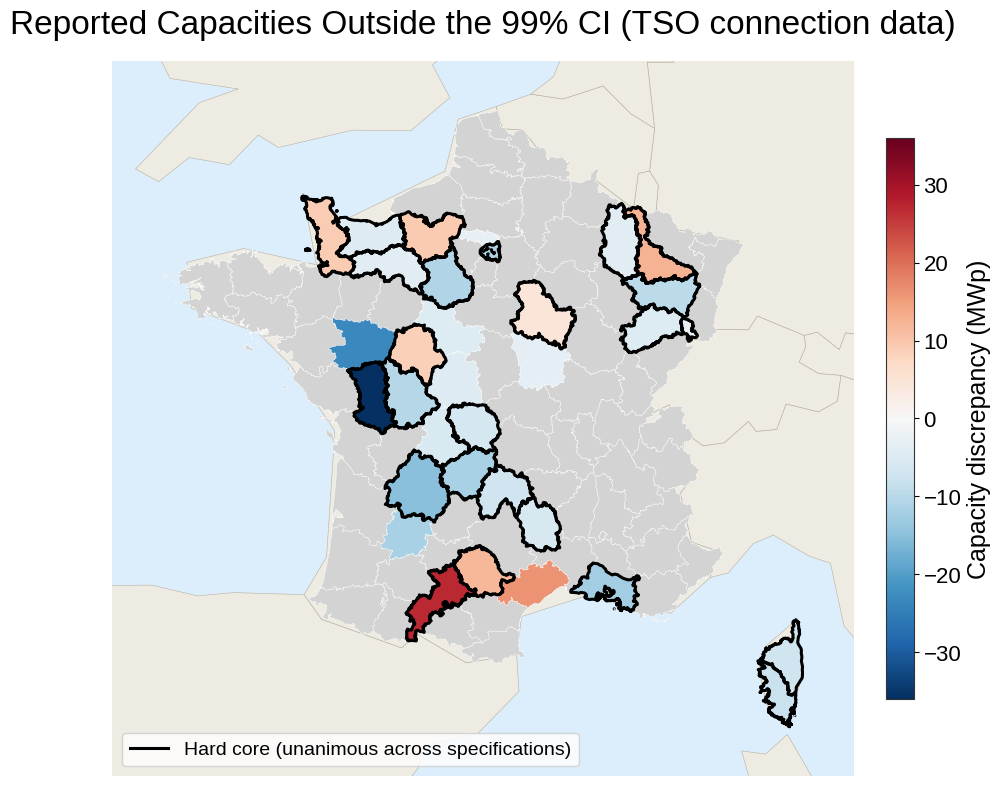

In [16]:
BASELINE_SPECS = ['A']        # <- confirm: is 'A' the count-based (baseline) spec?
HARDCORE_SPECS = ['A', 'B']   # agreement across both core specifications

def flag_status(df, specs):
    sel = [f'status_{s}' for s in specs]
    n_below = (df[sel] == 'below').sum(axis=1)
    n_above = (df[sel] == 'above').sum(axis=1)
    return np.select(
        [
            n_below == len(sel),
            n_above == len(sel),
            (n_below > 0) | (n_above > 0),
        ],
        ['below', 'above', 'mixed'],
        default='within',
    )

rb['status_baseline'] = flag_status(rb, BASELINE_SPECS)
rb['status_hardcore'] = flag_status(rb, HARDCORE_SPECS)

c = rb.copy()
c['spread'] = c['kWp_rte'] - c['p_inst_mean']
c['spread_MWp'] = c['spread'] / 1000

fig, ax = plt.subplots(figsize=(9, 9))

helpers.add_basemap(ax, c.total_bounds)
ax.set_aspect(1 / np.cos(np.radians(46.5)))


# ------------------------------------------------------------------
# Grey units: no data, or not flagged at the baseline
# ------------------------------------------------------------------
for st, color in [
    ('nodata', '#eeeeee'),
    ('within', 'lightgray'),
    ('mixed', 'lightgray'),
]:
    sub = c[c['status_baseline'] == st]
    if len(sub):
        sub.plot(
            ax=ax,
            color=color,
            edgecolor='white',
            linewidth=0.3,
            aspect=None,
            zorder=1,
        )


# ------------------------------------------------------------------
# Shared colour scale on the spread, at the baseline specification
# ------------------------------------------------------------------
flagged = c[c['status_baseline'].isin(['above', 'below'])]

if len(flagged):

    vmax = max(abs(flagged['spread_MWp']).max(), 1)
    norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
    cmap = plt.cm.RdBu_r

    flagged.plot(
        ax=ax,
        column='spread_MWp',
        cmap=cmap,
        norm=norm,
        edgecolor='white',
        linewidth=0.3,
        aspect=None,
        zorder=2,
    )

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm._A = []
    cbar = fig.colorbar(sm, ax=ax, fraction=0.035, pad=0.04)
    cbar.set_label('Capacity discrepancy (MWp)', fontsize=18)  # <- unit fix, see below
    cbar.ax.tick_params(labelsize=16)


# ------------------------------------------------------------------
# Hard-core outline: departments flagged unanimously under both
# core specifications (subset of `flagged`, by construction)
# ------------------------------------------------------------------
hardcore = c[c['status_hardcore'].isin(['above', 'below'])]

if len(hardcore):
    hardcore.plot(
        ax=ax,
        facecolor='none',
        edgecolor='black',
        linewidth=2.2,
        aspect=None,
        zorder=3,
    )

    # legend entry for the outline, since colour alone won't explain it
    from matplotlib.lines import Line2D
    hardcore_handle = Line2D(
        [0], [0],
        color='black',
        linewidth=2.2,
        label='Hard core (unanimous across specifications)',
    )
    ax.legend(handles=[hardcore_handle], loc='lower left', fontsize=14, frameon=True)


helpers._hide_axis_chrome(ax)

ax.set_title(
    "Reported Capacities Outside the 99% CI (TSO connection data)",
    fontsize=24,
    pad=20,
)

ax.set_xlabel(ax.get_xlabel(), fontsize=20)
ax.set_ylabel(ax.get_ylabel(), fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=18, width=1.5, length=6)
for spine in ax.spines.values():
    spine.set_linewidth(1.5)

fig.tight_layout()

helpers.save_fig(
    fig,
    f"{FIG_PREFIX}_status_map_baseline_{'_'.join(BASELINE_SPECS)}_hardcore_{'_'.join(HARDCORE_SPECS)}.pdf",
    FIGS_DIR,
)

plt.show()

## 6. External anchoring of the conversion coefficient

Specification C shows that the *national* level is sensitive to the surface-to-capacity
coefficient. This section anchors it against an external reference.

On the **within** units, where the registry is already compatible with the estimate and therefore
presumed complete, the distribution of estimated capacity per detected array should coincide with
the distribution of registry capacities. A systematic offset measures a bias in the coefficient
directly. Restricting to those units is what keeps the anchor non-circular: the coefficient is not
calibrated on the discrepancy it is later used to measure.

**A documented caveat.** The comparison is polluted by a difference of convention, a detected array
against an administrative installation: extensions and contract changes split a system on the
registry side, while clustering merges them on the detection side. It reads as an
order-of-magnitude anchor, not a fine calibration, and the median is preferred to the mean for
robustness to the tails.

The full treatment, including why a quantile-by-quantile reading does not conclude, is in
`0_pipeline/sanity_checks/conversion_factor_anchor.ipynb`.

> **This section does not run from the released data.**
>
> It needs the transmission system operator's per-installation extract, which is
> not redistributable. The aggregates released in its place (see
> `data/source/rte_derived/README.md`) carry every quantity the audit itself
> consumes, but not the full capacity distribution this section pools over.
>
> The section is kept, and its outputs ship in `data/intermediate`, so the
> result is inspectable even where the computation cannot be replayed. What is
> shipped instead is `rte_capacity_deciles.csv`, deciles for three illustrative
> units, which demonstrates the shape of the distribution without standing in
> for it.


In [17]:
RTE_FILE = ROOT / '0_data' / 'src' / 'rte' / 'installations_rte.csv'

# This section needs the operator's per-installation extract, which is not part of
# the release. When it is absent the section is skipped with a message rather than
# raising, so the notebook still runs end to end and the audit above completes.
RESTRICTED_OK = RTE_FILE.exists()
if not RESTRICTED_OK:
    print("SKIPPED: the conversion anchoring needs the per-installation registry extract,")
    print("which is not redistributable. See the banner above and the repository README.")
    print("Everything else in this notebook has run.")

if RESTRICTED_OK:
    DETECTIONS_FILE = ROOT / '0_data' / 'postprocess' / 'filtering' / paths.DETECTIONS

    rte_inst = pd.read_csv(RTE_FILE, dtype={'code_departement': str}, low_memory=False)
    det = gpd.read_file(DETECTIONS_FILE, columns=['dpt', 'kWp'], ignore_geometry=True)

    within_depts = set(comparison.loc[comparison['status_kwp'] == 'within', 'dpt'])
    rte_w = rte_inst[rte_inst['code_departement'].isin(within_depts)]
    det_w = det[det['dpt'].isin(within_depts)]

    med_rte, med_dpvm = rte_w['p_inst'].median(), det_w['kWp'].median()
    implied = 5.5 * med_dpvm / med_rte
    print(f"departements within : {len(within_depts)}")
    print(f"median capacity per record: detections {med_dpvm:.2f} | registry {med_rte:.2f}")
    print(f"coefficient implicite : 5.5 x {med_dpvm:.2f}/{med_rte:.2f} = {implied:.2f} m2/kWc")
    print(f"-> against the specification C range [5.0, 6.0]: "
          f"{'INSIDE, the range brackets it correctly' if 5.0 <= implied <= 6.0 else 'OUTSIDE, investigate'}")

    # quantiles compares
    qs = [0.1, 0.25, 0.5, 0.75, 0.9]
    qtab = pd.DataFrame({'DPVM': det_w['kWp'].quantile(qs), 'RTE': rte_w['p_inst'].quantile(qs)})
    qtab['ratio'] = qtab['DPVM'] / qtab['RTE']
    print()
    print(qtab.round(2))


SKIPPED: the conversion anchoring needs the per-installation registry extract,
which is not redistributable. See the banner above and the repository README.
Everything else in this notebook has run.


In [18]:
if RESTRICTED_OK:
    # Cumulative distributions on three within units, the best measured ones
    EXAMPLE_WITHIN = list(comparison[comparison['status_kwp'] == 'within']
                          .merge(calibration[['dpt', 'f1']], on='dpt')
                          .nlargest(3, 'f1')['dpt'])

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
    for ax, d_ in zip(axes, EXAMPLE_WITHIN):
        a = np.sort(det[det['dpt'] == d_]['kWp'].clip(upper=36))
        b = np.sort(rte_inst[rte_inst['code_departement'] == d_]['p_inst'].clip(upper=36))
        ax.plot(a, np.linspace(0, 1, len(a)), label='DPVM', color=style.COLOR_SOURCE_OSM)
        ax.plot(b, np.linspace(0, 1, len(b)), label='RTE', color=style.COLOR_REGISTRY)
        ax.set_title(f"Department {d_}", fontweight='bold')
        ax.set_xlabel('kWp per installation')
        ax.set_xlim(0, 15)
        ax.legend()
    axes[0].set_ylabel('ECDF')
    plt.tight_layout()
    helpers.save_fig(fig, f'{FIG_PREFIX}_conversion_anchor_ecdf.png', FIGS_DIR)
    plt.show()
